In [1]:
# 라이브러리 & 기본 옵션

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns

# 1) 윈도우 기본 맑은고딕 파일 경로
font_path = r"C:\Windows\Fonts\malgun.ttf"

# 2) 폰트를 matplotlib에 "강제 등록"
fm.fontManager.addfont(font_path)

# 3) 등록한 폰트의 정확한 이름 가져오기
font_name = fm.FontProperties(fname=font_path).get_name()

# 4) matplotlib + seaborn 둘 다에 폰트 강제 적용 (seaborn이 덮는 문제 방지)
mpl.rcParams["font.family"] = font_name
mpl.rcParams["font.sans-serif"] = [font_name]
mpl.rcParams["axes.unicode_minus"] = False

sns.set_theme(style="whitegrid", rc={
    "font.family": font_name,
    "font.sans-serif": [font_name],
    "axes.unicode_minus": False
})

***

In [2]:
# 0) 데이터 로드
df = pd.read_csv("../data/survey_response.csv")

# 데이터 확인
df.head(1)

,gender,age_group,region,cafe_visits_per_week,starbucks_visits_per_week,reserve_awareness_flag,reserve_awareness_channel,reserve_visited_flag,reserve_visit_purpose,reserve_service_used,reserve_service_reuse_flag,reserve_nonvisit_reason,reserve_ab_group,reserve_perception_change,reserve_improvement,reserve_recommend
0,여,20대,경기,2~3회,0~1회,Yes,"스타벅스 앱 / 매장(포스터, 이벤트)",Yes,일상적인 커피·음료 구매 목적 → 단순 가까운 위치/동선 상 편리해서,"리저브 전용 서비스를 이용하지 않음 (바 좌석 이용 X , 전용 음료 X)",No,NaN,B안 - 목적지형 : 공간·인테리어 / 지역성·스토리,5,가격 인하,5


**컬럼 정보**
- `gender` : 성별 (unique ID)
- `age_group` : 연령대
- `region` : 거주 지역
- `cafe_visits_per_week` : 주 평균 카페 방문 횟수
- `starbucks_visits_per_week` : 주 평균 스타벅스 방문 횟수
- `reserve_awareness_flag` : 리저브 인지 여부
- `reserve_awareness_channel` : 리저브 유입 경로
- `reserve_visited_flag` : 리저브 방문 경험
- `reserve_visit_purpose` : 리저브 방문 목적
- `reserve_service_used` : 리저브 전용 서비스 이용 경험
- `reserve_service_reuse_flag` : 리저브 전용 서비스 재이용 의사
- `page_coreserve_nonvisit_reasonnfirm` : 리저브 미방문 이유
- `reserve_ab_group` : 리저브 A/B 테스트
- `reserve_perception_change` : 리저브 인식 전환
- `reserve_improvement` : 리저브 개선 요구
- `reserve_recommend` : 리저브 추천 의향

***

### 📌 가설: (H03-1, 2)
- (H03-1) `“리저브 매장”`을 `“리저브 매장”`이라고 `인지하고 방문`하는 사람의 비율은 `타 응답`에 비해 `낮을 것이다`.<br><br>
- (H03-2) `“리저브 매장에 가긴 갔지만`, 리저브 경험(`전용서비스`)까지 간 비율이 `낮을 것이다`.(30% 미만)

In [3]:
# 1) 기술통계(퍼널) 정리
visited = df["reserve_visited_flag"].astype(str).str.strip().eq("Yes")

premium = df["reserve_visit_purpose"].astype(str).str.contains("프리미엄 커피", na=False)

# '이용하지 않음'이 아니면 = 전용 음료만/전체 이용(= 1개 이상 이용)으로 간주
# 즉 전용 서비스 이용했다는 사람
used_any = ~df["reserve_service_used"].astype(str).str.contains("이용하지 않음", na=False)

print("=== H03 퍼널 요약 ===")

# 전체 응답자
n_total = len(df)
print(f"전체 응답자: {n_total}명")

# 리저브 방문자 / 미방문자
n_visited = visited.sum()
n_not_visited = n_total-n_visited
print(f"리저브 방문자: {n_visited}명({(n_visited/n_total)*100:.1f})% / 리저브 미방문자: {n_not_visited}명({(n_not_visited/n_total)*100:.1f})%\n")

# 프리미엄 목적 선택자, 나머지 선택자
n_premium = (visited & premium).sum()
n_not_premium = n_visited - n_premium
print(f"리저브 방문자: {n_visited}명 중")
print(f"프리미엄 목적 선택자: {n_premium}명({(n_premium/n_visited)*100:.1f})% / 그 이외 나머지 선택자: {n_not_premium}명({(n_not_premium/n_visited)*100:.1f})%\n")

# 프리미엄 목적 + 전용서비스 이용자
n_premium_used = (visited & premium & used_any).sum()
print(f"프리미엄 목적 선택자: {n_premium}명 중")
print(f"프리미엄 목적 + 전용서비스 이용자: {n_premium_used}명({(n_premium_used/n_premium)*100:.1f})%")

# 프리미엄 목적 + 전용서비스 미이용자
n_premium_not_used = (visited & premium & ~used_any).sum()
print(f"프리미엄 목적 + 전용서비스 미이용자: {n_premium_not_used}명({(n_premium_not_used/n_premium)*100:.1f})%\n")

# 프리미엄 목적자 중 이용률
kpiA = n_premium_used / n_premium * 100
# 방문자 기준
kpiB = n_premium_used / n_visited * 100
# 전체 기준
kpiC = n_premium_used / n_total * 100

print("=== KPI ===")
print(f"KPI A(프리미엄 목적자 중): {n_premium_used}명 / {n_premium}명 = {kpiA:.1f}%")
print(f"KPI B(방문자 기준): {n_premium_used}명 / {n_visited}명 = {kpiB:.1f}%")
print(f"KPI C(전체 기준): {n_premium_used}명 / {n_total}명 = {kpiC:.1f}%")

=== H03 퍼널 요약 ===
전체 응답자: 200명
리저브 방문자: 126명(63.0)% / 리저브 미방문자: 74명(37.0)%

리저브 방문자: 126명 중
프리미엄 목적 선택자: 26명(20.6)% / 그 이외 나머지 선택자: 100명(79.4)%

프리미엄 목적 선택자: 26명 중
프리미엄 목적 + 전용서비스 이용자: 23명(88.5)%
프리미엄 목적 + 전용서비스 미이용자: 3명(11.5)%

=== KPI ===
KPI A(프리미엄 목적자 중): 23명 / 26명 = 88.5%
KPI B(방문자 기준): 23명 / 126명 = 18.3%
KPI C(전체 기준): 23명 / 200명 = 11.5%


#### ☑️ 기술통계(퍼널) 요약
1. <span style="color:orange">전체 응답자: 200명</span>

|<span style="color:red">리저브 방문자</span>|<span style="color:skyblue">리저브 미방문자</span>|
|:---:|:---:|
|126명(`63.0`)%|74명(`37.0`)%|

<br>

2. <span style="color:orange">리저브 방문자: 126명 중</span>

|<span style="color:red">프리미엄 목적 선택자</span>|<span style="color:skyblue">그 이외 나머지 선택자</span>|
|:---:|:---:|
|26명(`20.6`)%|100명(`79.4`)%|

<br>

3. <span style="color:orange">프리미엄 목적 선택자: 26명 중</span>

|<span style="color:red">프리미엄 목적 + 전용서비스 이용자</span>|<span style="color:skyblue">프리미엄 목적 + 전용서비스 미이용자</span>|
|:---:|:---:|
|23명(`88.5`)%|3명(`11.5`)%|

<br>

4. <span style="color:orange">KPI</span>

|KPI A(프리미엄 목적자 중)|KPI B(방문자 기준)|KPI C(전체 기준)|
|:---:|:---:|:---:|
|23명 / 26명 = `88.5%`|23명 / 126명 = `18.3%`|23명 / 200명 = `11.5%`|

***

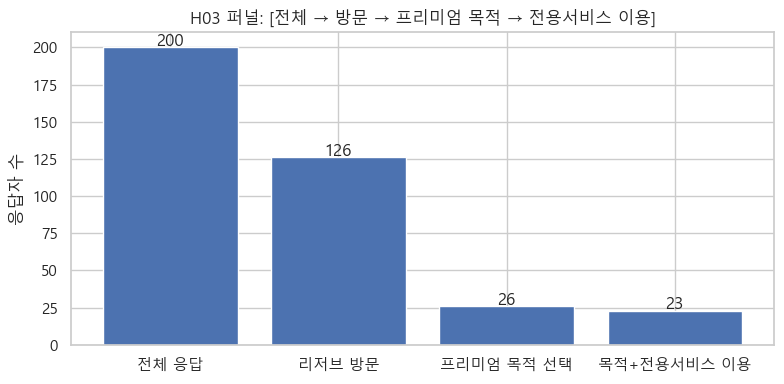

In [4]:
# 2) 시각화: 퍼널 막대그래프
labels = ["전체 응답", "리저브 방문", "프리미엄 목적 선택", "목적+전용서비스 이용"]
values = [n_total, n_visited, n_premium, n_premium_used]

plt.figure(figsize=(8,4))
plt.bar(labels, values)
plt.title("H03 퍼널: [전체 → 방문 → 프리미엄 목적 → 전용서비스 이용]")
plt.ylabel("응답자 수")
for i, v in enumerate(values):
    plt.text(i, v + 1, str(v), ha="center")
plt.tight_layout()
plt.show()

***

In [5]:
# 3-1) KPI_B의 95% 신뢰구간(“진짜 비율이 어느 범위인지”)
# CI 상한이 30%보다도 낮으면 → “30% 미만(낮다)” 주장 매우 강함
# CI가 30%를 걸치면 → “낮을 가능성은 있지만 단정은 어렵다”

from scipy.stats import binomtest

# KPI_B 기준: 방문자 중 전용서비스까지 이용
x = n_premium_used   # 23
n = n_visited        # 126

bt = binomtest(k=x, n=n)
ci = bt.proportion_ci(confidence_level=0.95, method="wilson")  # 윌슨 CI 권장

print(f"KPI_B = {x/n*100:.1f}%")
print(f"95% CI (Wilson): {ci.low*100:.1f}% ~ {ci.high*100:.1f}%")

KPI_B = 18.3%
95% CI (Wilson): 12.5% ~ 25.9%


***

In [6]:
# 3-2) 단측 이항검정(“30% 미만이 맞나?”)
# p < 0.05 → “30%보다 유의하게 낮다” (H1 지지)
# p ≥ 0.05 → “30%보다 낮다고 말하기엔 근거 부족”

p0 = 0.30  # 기준

bt_less = binomtest(k=x, n=n, p=p0, alternative="less")
print(f"H1: KPI_B < {p0}  -> p-value = {bt_less.pvalue:.4f}")

H1: KPI_B < 0.3  -> p-value = 0.0019


***

#### 📌 최종 인사이트

> 1. `리저브 방문자 126명` 중 `프리미엄 목적 선택자`는 `26명(20.6)%`, `그 이외 나머지 선택자`는 `100명(79.4)%`. <span style="color:orange">(거의 4배 차이)</span><br>
↪︎ 즉, “리저브 매장”을 “리저브 매장”이라고 `인지하고 방문`하는 사람들은 <span style="color:red">매우 낮음</span>.<br><br>
> 2. `전체 설문 응답자 200명`중 `리저브 방문자`는 `126명`으로 `63.0%`에 해당하였지만 <span style="color:skyblue">KPI_B: 프리미엄 목적 + 전용서비스</span> 이용자는 `126명` 대비 `23명`인 `18.3%`로 <span style="color:red">낮음</span>.<br><br>
> 3. `KPI_B의 95% CI`는 `12.5% ~ 25.9%`로 30%보다 `낮은 범위`에 있고,<br>
`단측 검정`에서도 `p=0.0019`로 `30% 미만`이 `유의`.<br><br>
> 4. <span style="color:orange">결론</span><br>
↪︎ 리저브는 `‘방문’은 발생`하지만, `‘리저브 경험(전용서비스)’`으로 `전환`되는 비율이 <span style="color:red">낮음</span>.<br>-> <span style="color:orange">따라서 전용서비스 안내/혜택/동선 설계가 필요.</span>